In [1]:
import os


In [3]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay

In [5]:
dataset_path = "Rice_Image_Dataset"

In [6]:
images = []
labels = []
IMG_SIZE = 64
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)
            image = cv2.imread(image_path)
            if image is None:
                continue
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            feature = image.flatten()
            images.append(feature)
            labels.append(folder)
            


In [ ]:
X = np.array(images)
y = np.array(labels)

print("Dataset shape", X.shape)

Dataset shape (69997, 12288)


Dataset shape (70012, 12288)


In [8]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("\nClasses:")

for i, cls in enumerate(encoder.classes_):
    print(i, ":", cls)


Classes:
0 : Arborio
1 : Basmati
2 : Ipsala
3 : Jasmine
4 : Karacadag
5 : pred


In [9]:
X_train, X_test, y_train, y_test =train_test_split(
    X, y,
    test_size=0.2,
    random_state = 42,
    stratify=y
)

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=1
)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
y_pred = model.predict(X_test)


In [12]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy*100)
# print(f"\nAccuracy : {:.2f}%.format{accuracy*100}")

99.39298721702492


In [13]:
cf = classification_report(y_test, y_pred)
print("Classifcation report",cf)

Classifcation report               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3000
           1       0.99      1.00      1.00      3000
           2       1.00      1.00      1.00      3000
           3       0.99      0.99      0.99      2000
           4       1.00      0.99      0.99      3000
           5       0.00      0.00      0.00         3

    accuracy                           0.99     14003
   macro avg       0.83      0.83      0.83     14003
weighted avg       0.99      0.99      0.99     14003



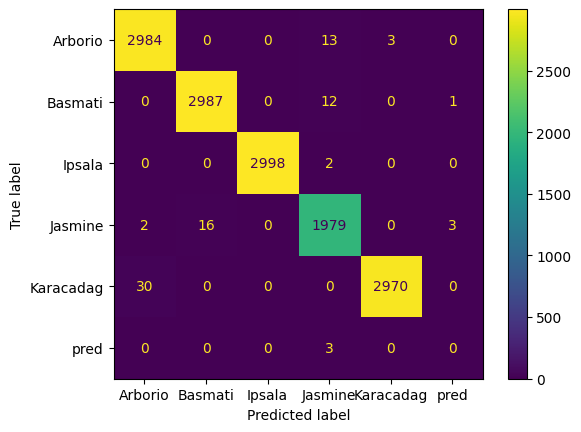

In [14]:
cn = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cn,
    display_labels = encoder.classes_
)

disp.plot()
plt.show()

In [15]:
joblib.dump(model, "rice_ml_model.pkl")
joblib.dump(encoder,"label_encoder.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully


In [ ]:
image_path = r""
image = cv2.imread(image_path)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

In [35]:
pred = r"Rice_Image_Dataset\pred"

images = []
IMG_SIZE = 64
for img in os.listdir(pred):
    img_path = os.path(pred, img)
    image = cv2.imread(img_path)
    # print(image)
    if image is None:
        continue
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    print(image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    feature = image.flatten()
    images.append(feature)

prediction = model.predict(images)
print(prediction)

TypeError: 'module' object is not callable